<a href="https://colab.research.google.com/github/KCCalder/MIR-Cetacean-Calls/blob/main/MIR_Cetacean_Calls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install librosa
!pip install mir_eval

import librosa
import mir_eval
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
import scipy as scp
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 3.9 MB/s eta 0:00:00


In [7]:
# Load all .wav files from a folder, returns signals and sample rate
def load_from_folder(folder_path):
  audio_clips = []
  sample_rates = []

  for file in os.listdir(folder_path):
    if file.endswith(".wav"):
        file_path = os.path.join(folder_path, file)
        y, sr = librosa.load(file_path, sr=None)
        audio_clips.append(y)
        sample_rates.append(sr)
  return audio_clips, sample_rates

# Spectral gating noise reduction
def spectral_gate(signal, sr, threshold=1.5):
    d = librosa.stft(signal)
    S, phase = np.abs(d), np.angle(d)

    noise_profile = np.median(S, axis=1, keepdims=True)
    mask = S > threshold * noise_profile

    S_denoised = S * mask
    d_denoised = S_denoised * np.exp(1j * phase)

    return librosa.istft(d_denoised)

In [3]:
# Data folder paths
srkw_training_path = "/content/drive/MyDrive/Orchive Project/SRKW_train"
humpback_training_path = "/content/drive/MyDrive/Orchive Project/Humpback_train"
negative_training_path = "/content/drive/MyDrive/Orchive Project/Negative_train"

In [4]:
# Load in the data (may take a while ~1 min)
srkw_clips, srkw_sr = load_from_folder(srkw_training_path)
humpback_clips, humpback_sr = load_from_folder(humpback_training_path)
negative_clips, negative_sr = load_from_folder(negative_training_path)

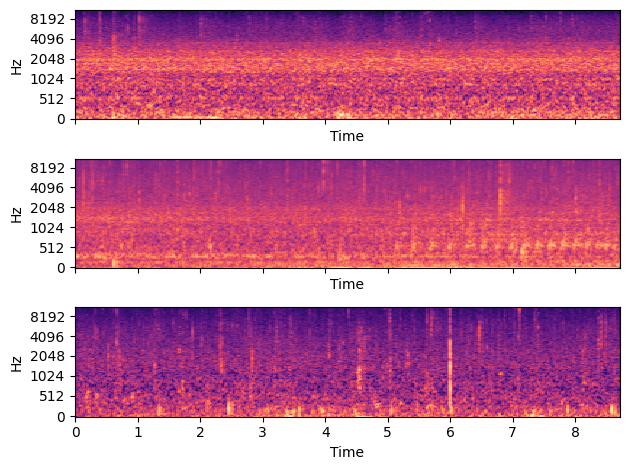

In [6]:
fig, ax = plt.subplots(nrows=3, sharex=True)

# Example of a SRKW spectrogram
ex_srkw_plot = librosa.feature.melspectrogram(y=srkw_clips[0], sr=srkw_sr[0])
librosa.display.specshow(librosa.power_to_db(ex_srkw_plot, ref=np.max), y_axis='mel', x_axis='time', ax=ax[0])

# Example of a Humpback spectrogram
ex_humpback_plot = librosa.feature.melspectrogram(y=humpback_clips[0], sr=humpback_sr[0])
librosa.display.specshow(librosa.power_to_db(ex_humpback_plot, ref=np.max), y_axis='mel', x_axis='time', ax=ax[1])

# Example of a Negative spectrogram
ex_negative_plot = librosa.feature.melspectrogram(y=negative_clips[0], sr=negative_sr[0])
librosa.display.specshow(librosa.power_to_db(ex_negative_plot, ref=np.max), y_axis='mel', x_axis='time', ax=ax[2])

plt.tight_layout()

In [17]:
denoise_srkw = spectral_gate(srkw_clips[0], srkw_sr[0])

denoise_humpback = spectral_gate(humpback_clips[0], humpback_sr[0])
ipd.Audio(denoise_humpback, rate=srkw_sr[0])

